## Demand Estimation and Market Analysis: Air Fryers

### Dishitha Dhakshin (qxk8wp), Emerson Brown (gsz5cv)

## 3. Strategy: Costs, Markups, and Profit

In [32]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

In [33]:
df = pd.read_csv('air_fryers_clean_brand_year.csv')
df.head()

,category,year,brand,purchase_count,product_count,avg_price,avg_rating,compact_share,dual_basket_share,oven_style_share,rotisserie_share,window_share,market_purchases,brand_share,log_brand_share
0,air_fryers,2019,chefman,1146,10,72.963695,4.434119,1.000000,0.0,0.780977,0.243455,0.184119,15076,0.076015,-2.576826
1,air_fryers,2019,cosori,11,2,159.990000,4.581818,1.000000,0.0,0.090909,0.090909,0.000000,15076,0.000730,-7.222964
2,air_fryers,2019,cuisinart,1616,22,229.465274,4.481312,0.993812,0.0,0.889851,0.000000,0.000000,15076,0.107190,-2.233150
3,air_fryers,2019,dash,3011,19,55.176333,4.390767,1.000000,0.0,0.973431,0.000000,0.000000,15076,0.199721,-1.610832
4,air_fryers,2019,gowise usa,4405,45,83.575551,4.552259,0.999773,0.0,0.129398,0.128490,0.000000,15076,0.292186,-1.230364


In [34]:
feature_cols = [
    'compact_share', 'dual_basket_share', 'oven_style_share',
    'rotisserie_share', 'window_share'
]

y = df['log_brand_share']

brand_dummies = pd.get_dummies(df['brand'],
                               prefix='brand', drop_first=True, dtype=int)
year_dummies = pd.get_dummies(df['year'].astype(str),
                              prefix='year', drop_first=True, dtype=int)

X = pd.concat(
    [df[['avg_price', 'avg_rating'] + feature_cols],
     brand_dummies,
     year_dummies],
    axis=1
)

model = LinearRegression()
model.fit(X, y)

predicted_log_share = model.predict(X)
r2 = r2_score(y, predicted_log_share)

coef_table = pd.DataFrame({
    'feature': X.columns,
    'coefficient': model.coef_
})

price_coef = coef_table.loc[coef_table['feature'] == 'avg_price', 'coefficient'].iloc[0]
print('Estimated price coefficient:', price_coef)

Estimated price coefficient: -0.03766765298429369


In [35]:
# Compute

df['demand_slope'] = price_coef * df['brand_share'] * (1 - df['brand_share'])

df['unit_cost'] = df['avg_price'] + ( price_coef / df['demand_slope'] )

df['markup'] = df['avg_price'] - df['unit_cost']

df['average_profit'] = df['brand_share'] * df['markup']

df.head()

,category,year,brand,purchase_count,product_count,avg_price,avg_rating,compact_share,dual_basket_share,oven_style_share,rotisserie_share,window_share,market_purchases,brand_share,log_brand_share,demand_slope,unit_cost,markup,average_profit
0,air_fryers,2019,chefman,1146,10,72.963695,4.434119,1.000000,0.0,0.780977,0.243455,0.184119,15076,0.076015,-2.576826,-0.002646,87.201286,-14.237591,-1.082268
1,air_fryers,2019,cosori,11,2,159.990000,4.581818,1.000000,0.0,0.090909,0.090909,0.000000,15076,0.000730,-7.222964,-0.000027,1531.536185,-1371.546185,-1.000730
2,air_fryers,2019,cuisinart,1616,22,229.465274,4.481312,0.993812,0.0,0.889851,0.000000,0.000000,15076,0.107190,-2.233150,-0.003605,239.914542,-10.449267,-1.120059
3,air_fryers,2019,dash,3011,19,55.176333,4.390767,1.000000,0.0,0.973431,0.000000,0.000000,15076,0.199721,-1.610832,-0.006021,61.432872,-6.256539,-1.249565
4,air_fryers,2019,gowise usa,4405,45,83.575551,4.552259,0.999773,0.0,0.129398,0.128490,0.000000,15076,0.292186,-1.230364,-0.007790,88.410826,-4.835276,-1.412801


In [36]:
df[['unit_cost', 'markup']].describe()

,unit_cost,markup
count,50.000000,50.000000
mean,169.606486,-46.800353
std,204.722133,192.202305
min,61.432872,-1371.546185
25%,101.752487,-20.957153
50%,119.236238,-13.805933
75%,181.216640,-8.188203
max,1531.536185,-4.835276


The typical units costs are $169.61 across brands and the markups were about -$46.80, indicating that they were marking down prices by that price. 

In [37]:
(df['unit_cost'] < 0).sum()

np.int64(0)

None of the inferred unit costs were negative.

In [38]:
df.groupby('brand')['unit_cost'].mean().sort_values(ascending = False)

brand
cosori         422.732112
cuisinart      237.358264
oster          233.503406
nuwave         160.131940
ninja          151.843831
instant_pot    122.324623
chefman        103.628535
gowise usa      99.397480
ultrean         93.556244
dash            71.588425
Name: unit_cost, dtype: float64

Cosori has the highest average unit costs, followed by Cuisinart and Oster.

In [39]:
df.groupby('brand')['markup'].mean().sort_values(ascending=False)

brand
ninja           -6.501290
gowise usa     -11.942699
chefman        -12.690123
cuisinart      -13.411171
dash           -14.109498
ultrean        -15.441638
instant_pot    -17.863271
nuwave         -23.107556
oster          -44.472122
cosori        -308.464162
Name: markup, dtype: float64

Ninja has the highest average markups, but overall it still has an average of marking down their prices by about $6.50. 

In [40]:
df.groupby('brand')['average_profit'].mean().sort_values(ascending = False)

brand
oster         -1.025551
nuwave        -1.053596
cosori        -1.054115
cuisinart     -1.094282
ultrean       -1.104749
chefman       -1.106259
dash          -1.112791
gowise usa    -1.173488
instant_pot   -1.226392
ninja         -1.237536
Name: average_profit, dtype: float64

All of the brands have relatively close share-weighted average profits, but while it is still negative, Oster has the highest at -$1.03.

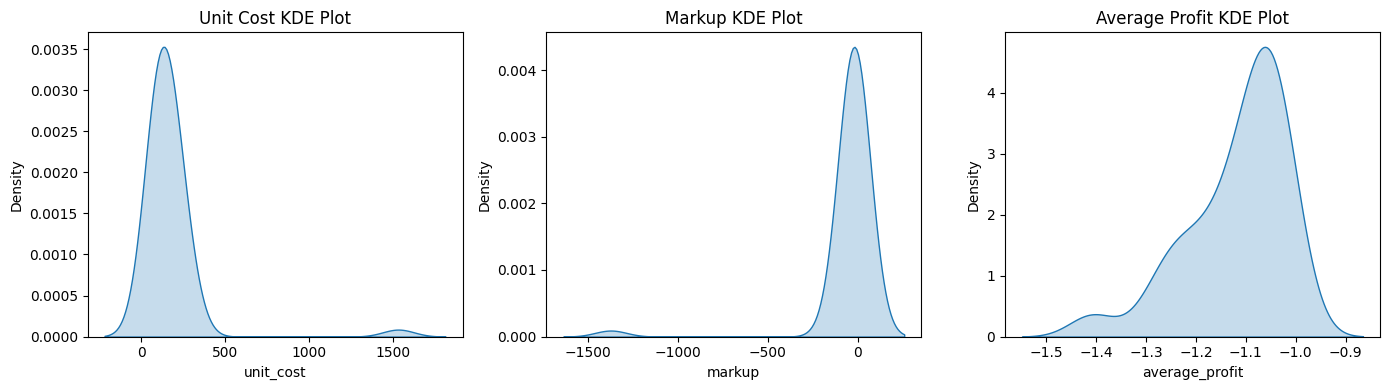

In [41]:
fig, axes = plt.subplots(1, 3, figsize=(14,4))
sns.kdeplot(df['unit_cost'], ax=axes[0], fill = True)
axes[0].set_title('Unit Cost KDE Plot')
sns.kdeplot(df['markup'], ax = axes[1], fill = True)
axes[1].set_title('Markup KDE Plot')
sns.kdeplot(df['average_profit'], ax = axes[2], fill = True)
axes[2].set_title('Average Profit KDE Plot')
plt.tight_layout()
plt.show()

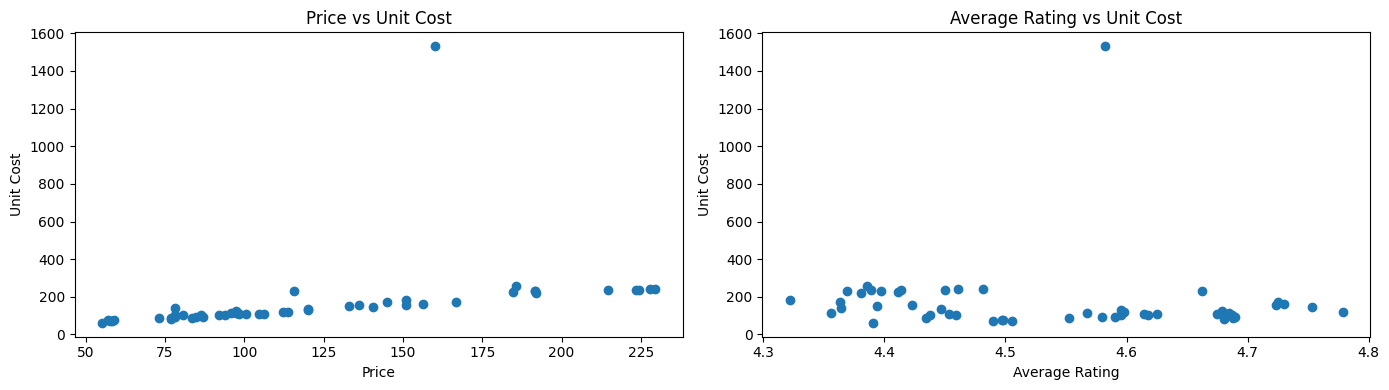

In [42]:
fig, axes = plt.subplots(1, 2, figsize = (14,4))
axes[0].scatter(df['avg_price'], df['unit_cost'])
axes[0].set_xlabel('Price')
axes[0].set_ylabel('Unit Cost')
axes[0].set_title('Price vs Unit Cost')
axes[1].scatter(df['avg_rating'], df['unit_cost'])
axes[1].set_xlabel('Average Rating')
axes[1].set_ylabel('Unit Cost')
axes[1].set_title('Average Rating vs Unit Cost')
plt.tight_layout()
plt.show()


In [43]:
df['demand_slope'] * df['markup'] + df['brand_share']

0     0.113683
1     0.038397
2     0.144858
3     0.237389
4     0.329854
5     0.053454
6     0.230292
7     0.069772
8     0.071231
9     0.087747
10    0.095804
11    0.046251
12    0.139810
13    0.139150
14    0.208147
15    0.180812
16    0.203393
17    0.117031
18    0.052061
19    0.194216
20    0.121946
21    0.072805
22    0.124604
23    0.120520
24    0.153454
25    0.237732
26    0.220002
27    0.088559
28    0.061687
29    0.175366
30    0.154397
31    0.110708
32    0.114738
33    0.088397
34    0.095905
35    0.324230
36    0.236726
37    0.072152
38    0.063881
39    0.115543
40    0.177906
41    0.165049
42    0.093263
43    0.092191
44    0.091001
45    0.266715
46    0.255763
47    0.093620
48    0.063858
49    0.077311
dtype: float64